# Coding challenge - Andrea Álvarez 

## 1. Preprocessing 

In [163]:
import pandas as pd
import os
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 1.1 Load and explore data

In [164]:
print(os.getcwd())
df = pd.read_csv('loan_dataset.csv',index_col=False,delimiter=";")   

/Users/andreaalvarezsanchez/Desktop/GitHub/coding-challenge-data-gov-fintech


Let's start by taking a look at the data, the number of variables, the observations, and the type of data we work with. 

In [165]:
print(df.head())
df.info()
print("\nDataset shape:", df.shape)

print("\nColumns:", df.columns.tolist())

   customer_id  age  ...  payment_to_income_ratio  loan_status
0        35467   63  ...                    0.234       repaid
1        23067   38  ...                    0.193       repaid
2         8591   48  ...                    0.214       repaid
3         9983   52  ...                    0.389       repaid
4        21525   55  ...                    0.500      default

[5 rows x 22 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  int64  
 1   age                      50000 non-null  int64  
 2   income                   50000 non-null  float64
 3   loan_amount              50000 non-null  float64
 4   loan_term_months         50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   employment_length_years  50000 non-null  float64
 7  

Some columns look irrelevant at first sights for the purpose of our analysis, so we proceed to drop them. 

In [166]:
# Drop irrelevant columns
columns_to_drop = ['customer_id', 'application_date']  #for now those are the ones I want to drop
df_clean = df.drop(columns=columns_to_drop)

print("\nShape after dropping columns:", df_clean.shape)


Shape after dropping columns: (50000, 20)


### 1.2 Examine and handle categorical variables 

In [167]:
df_clean['zip_code_prefix'] = df_clean['zip_code_prefix'].astype('category') #did not appear as categoric and the description says it should be treated as one
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print("The categorical columns are:", categorical_cols)

# Count unique values per categorical column
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts(normalize=True))  

The categorical columns are: ['education_level', 'zip_code_prefix', 'home_ownership', 'application_type', 'loan_purpose', 'loan_status']

--- education_level ---
education_level
bachelors      0.39754
high_school    0.30072
masters        0.20126
phd            0.10048
Name: proportion, dtype: float64

--- zip_code_prefix ---
zip_code_prefix
30    0.30068
20    0.24646
40    0.20134
10    0.14900
50    0.10252
Name: proportion, dtype: float64

--- home_ownership ---
home_ownership
mortgage    0.40480
rent        0.34892
own         0.24628
Name: proportion, dtype: float64

--- application_type ---
application_type
online       0.60480
in_person    0.29648
phone        0.09872
Name: proportion, dtype: float64

--- loan_purpose ---
loan_purpose
debt_consolidation    0.39742
car                   0.20214
business              0.15094
home_improvement      0.14912
other                 0.10038
Name: proportion, dtype: float64

--- loan_status ---
loan_status
repaid     0.62432
default    0

From the results of the percentage of data of each type, we can notice that the category 'phd' in the variable education has a percentage low but stil considerable (around 10%), so we will not delete it. The category 'phone' has a more pronunced low percentage (~10%), but still reasonable, so we will keep it for now.

Now, let's do a copy of the dataframe. Then, we first map our target variable and then we enconde the rest of the categorical variables that are in the dataset, setting as the baseline the categories that are more common. 

In [168]:
df_encoded = df_clean.copy()

df_encoded['loan_status'] = df_encoded['loan_status'].map({'repaid': 0, 'default': 1}) #If pd.get_dummies() on everything at once, you risk turning your target into dummy columns too

categorical_cols = ['education_level', 'home_ownership', 'application_type', 'loan_purpose', 'zip_code_prefix']

edu_order = CategoricalDtype(['bachelors', 'high_school', 'masters', 'phd'], ordered=True)
df_clean['education_level'] = df_clean['education_level'].astype(edu_order)

zip_order = CategoricalDtype(['30', '20', '40', '10', '50'], ordered=True)
df_clean['zip_code_prefix'] = df_clean['zip_code_prefix'].astype(zip_order)

home_order = CategoricalDtype(['mortgage', 'rent', 'own'], ordered=True)
df_clean['home_ownership'] = df_clean['home_ownership'].astype(home_order)

app_order = CategoricalDtype(['online', 'in_person', 'phone'], ordered=True)
df_clean['application_type'] = df_clean['application_type'].astype(app_order)

loan_purpose_order = CategoricalDtype(['debt_consolidation', 'car', 'business', 'home_improvement', 'other'], ordered=True)
df_clean['loan_purpose'] = df_clean['loan_purpose'].astype(loan_purpose_order)

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", df_encoded.shape)
print("\nColumns after encoding:", df_encoded.columns.tolist())

# Check that target is numeric
print(df_encoded['loan_status'].unique())  # Should return [0, 1]




Shape after encoding: (50000, 30)

Columns after encoding: ['age', 'income', 'loan_amount', 'loan_term_months', 'credit_score', 'employment_length_years', 'debt_to_income_ratio', 'savings_amount', 'previous_defaults', 'has_cosigner', 'existing_customer', 'loan_to_income_ratio', 'monthly_payment', 'payment_to_income_ratio', 'loan_status', 'education_level_high_school', 'education_level_masters', 'education_level_phd', 'home_ownership_own', 'home_ownership_rent', 'application_type_online', 'application_type_phone', 'loan_purpose_car', 'loan_purpose_debt_consolidation', 'loan_purpose_home_improvement', 'loan_purpose_other', 'zip_code_prefix_20', 'zip_code_prefix_30', 'zip_code_prefix_40', 'zip_code_prefix_50']
[0 1]


### Summary Statistics

In [169]:
numerical_cols_clean = [
    'age', 'income', 'loan_amount', 'loan_term_months', 'credit_score',
    'employment_length_years', 'debt_to_income_ratio', 'savings_amount',
    'previous_defaults', 'loan_to_income_ratio', 'monthly_payment', 'payment_to_income_ratio'
]
df_encoded[numerical_cols_clean].describe(),round(2)

(                age         income  ...  monthly_payment  payment_to_income_ratio
 count  50000.000000   50000.000000  ...     50000.000000             50000.000000
 mean      44.002820   60133.980000  ...       752.350952                 0.173547
 std       15.269871   29597.663249  ...       619.605202                 0.135225
 min       18.000000   20000.000000  ...        18.870000                 0.003000
 25%       31.000000   38000.000000  ...       361.560000                 0.072000
 50%       44.000000   55000.000000  ...       583.490000                 0.130000
 75%       57.000000   76000.000000  ...       934.990000                 0.236000
 max       70.000000  300000.000000  ...      7644.750000                 0.500000
 
 [8 rows x 12 columns],
 2)

We reviewed the summary statistics for all numerical variables to understand the basic distribution of the data. Most variables appear to be within reasonable and expected ranges. For example, income ranges from €20,000 to €300,000, with a median around €55,000, while loan amounts vary between €1,000 and €121,700, with a median of approximately €18,700. The credit score distribution is centered around 708, and savings amounts show a wide range, from €0 up to about €183,000. Ratios like loan-to-income and payment-to-income are skewed towards lower values but reach maximums of 2.0 and 0.5, respectively. Overall, no unusual values or data entry errors were detected, and the statistics align well with typical patterns found in financial lending data.

We also examined the distribution of categorical variables in another section, which confirmed good variety across categories and provided a solid foundation for modeling. For example, regarding the education level, the majority of applicants have a bachelor’s degree (about 40%) or a high school diploma (30%), with smaller groups holding masters (20%) and PhD degrees (10%) or, the target variable, loan status, shows that around 62% of loans were repaid, while 38% defaulted. 

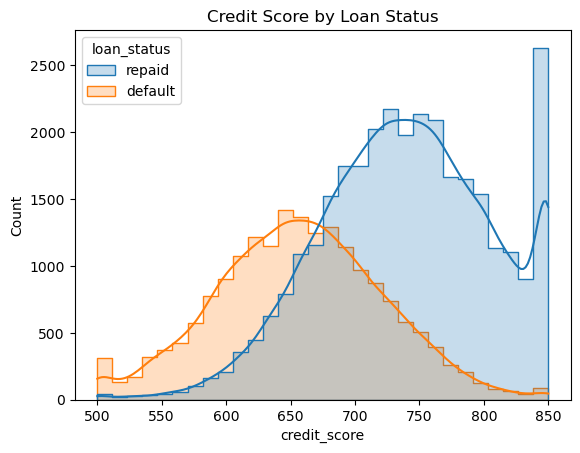

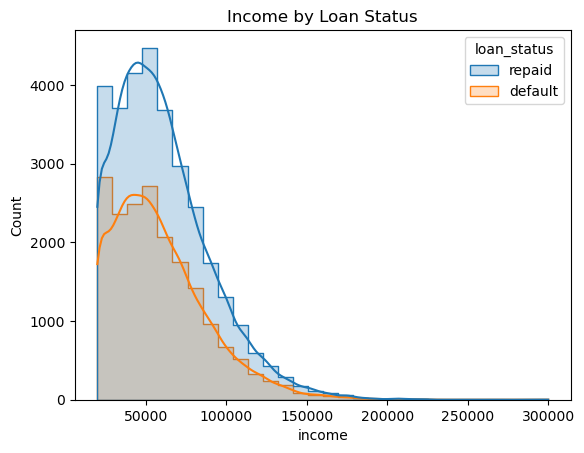

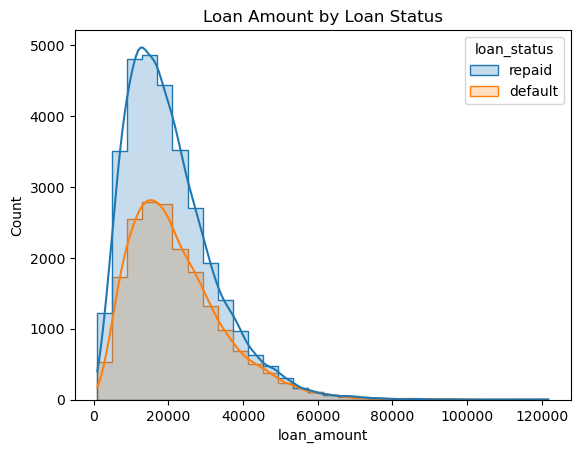

In [170]:
sns.histplot(data=df_clean, x='credit_score', hue='loan_status', bins=30, kde=True, element="step")
plt.title("Credit Score by Loan Status")
plt.show()

sns.histplot(data=df_clean, x='income', hue='loan_status', bins=30, kde=True, element="step")
plt.title("Income by Loan Status")
plt.show()

# Loan amount distribution
sns.histplot(data=df_clean, x='loan_amount', hue='loan_status', bins=30, kde=True, element="step")
plt.title("Loan Amount by Loan Status")
plt.show()


In here, we took look at how some important variables (like income or credit score) change depending on whether the loan was repaid or defaulted.
These plots help us see if there are clear differences between the two groups. For instance we see that people with higher income and higher credit scores are more likely to repay their loans and people who default tend to have lower income and lower credit scores.
We also notice that some values, like income and loan amount, are not evenly spread — most people have low values, and a few have very high ones. This is normal in financial data, but we may decide later to apply a transformation (like a taking logs) to make it easier for the model to learn. These graphs are helpful to get an idea of what matters before building the model.

To complement the visual distributions, we now report group-level means and standard deviations for key numerical variables. This allows us to see average differences between repaid and defaulted loans, which can help us understand potential predictors.
As expected, repaid loans are associated with higher income and credit scores on average, and moderately lower loan amounts.

In [171]:
vars_to_compare = ['income', 'loan_amount', 'credit_score']

grouped_stats = df_clean.groupby('loan_status')[vars_to_compare].agg(['mean', 'std']).round(2)
print("\nGroup-level summary statistics:")
print(grouped_stats)


Group-level summary statistics:
               income           loan_amount           credit_score       
                 mean       std        mean       std         mean    std
loan_status                                                              
default      58884.26  29512.37     22116.2  12557.50       657.08  65.60
repaid       60885.99  29623.94     20393.3  11868.62       739.48  65.87


We confirm what we saw in the graphs: credit score seems to matter a lot, and loan size might also be important.

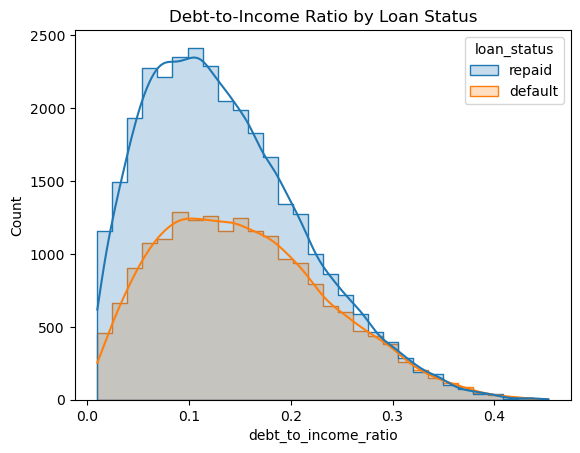

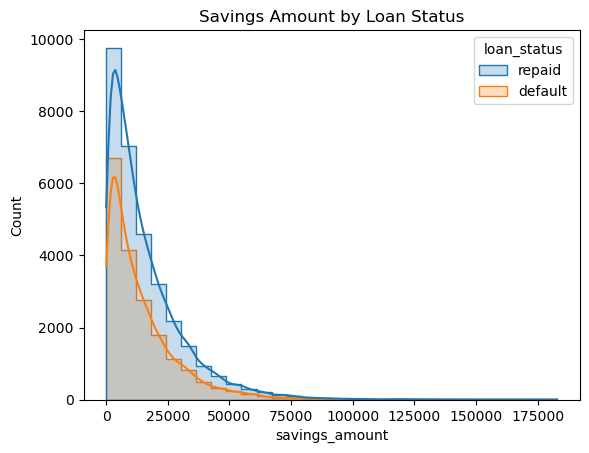

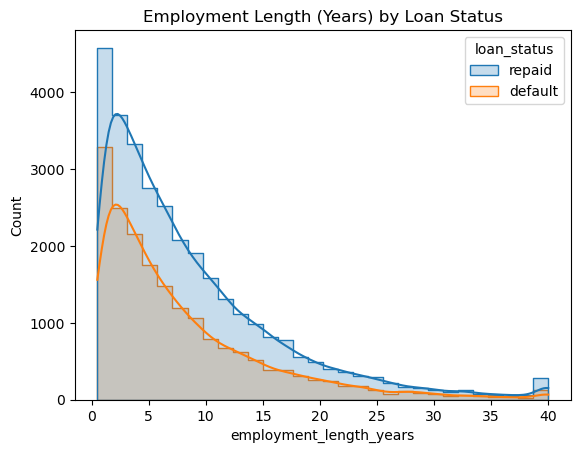

In [172]:
# Debt-to-income ratio
sns.histplot(data=df_clean, x='debt_to_income_ratio', hue='loan_status', bins=30, kde=True, element="step")
plt.title("Debt-to-Income Ratio by Loan Status")
plt.show()

# Savings amount
sns.histplot(data=df_clean, x='savings_amount', hue='loan_status', bins=30, kde=True, element="step")
plt.title("Savings Amount by Loan Status")
plt.show()

# Employment length
sns.histplot(data=df_clean, x='employment_length_years', hue='loan_status', bins=30, kde=True, element="step")
plt.title("Employment Length (Years) by Loan Status")
plt.show()


We now check some other features that might help us understand loan defaults better.

- People who defaulted usually have a higher debt-to-income ratio. This means they spend more of their income paying debts.
- Their savings amounts are often lower, with many having no savings at all.
- They also tend to have shorter employment histories compared to those who repaid.

These patterns suggest that having more financial pressure and less job stability may increase the chance of defaulting on a loan.

### Outliers detection

Afterwards, we focus on detecting potential outliers in the numerical variables of our dataset. Outliers can significantly affect certain machine learning models, especially linear ones like logistic regression. To systematically identify outliers, we apply the Interquartile Range (IQR) method, which flags observations that fall well outside the typical range of values (1.5 times the IQR below the first quartile or above the third quartile). We also visualize distributions using boxplots to better understand where do extreme values appear. This allows us to decide what to do with those outliers (removed, capped, or retained), depending on their frequency and potential impact on model performance.


This are the numerical columns: ['age', 'income', 'loan_amount', 'loan_term_months', 'credit_score', 'employment_length_years', 'debt_to_income_ratio', 'savings_amount', 'previous_defaults', 'has_cosigner', 'existing_customer', 'loan_to_income_ratio', 'monthly_payment', 'payment_to_income_ratio', 'loan_status']


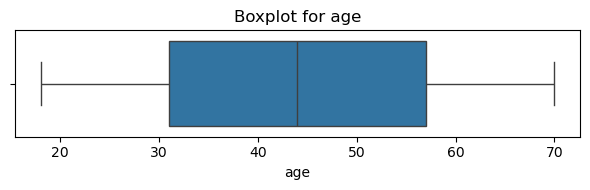

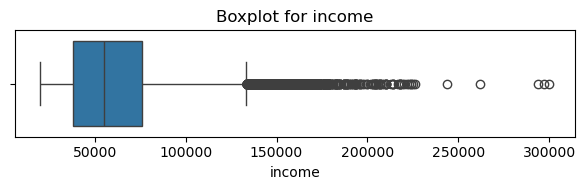

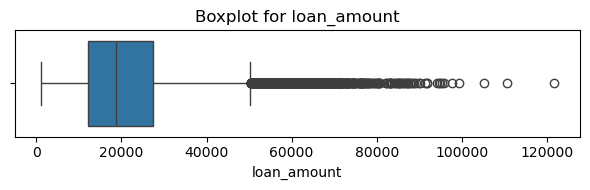

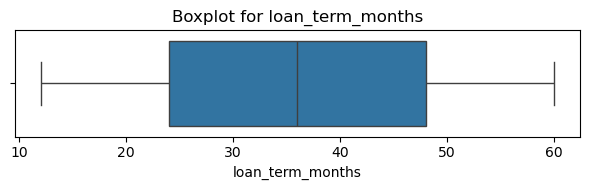

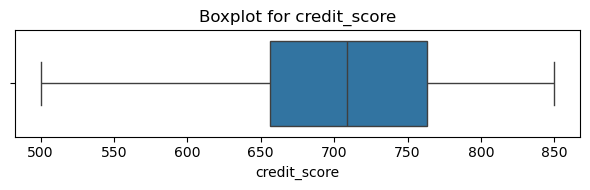

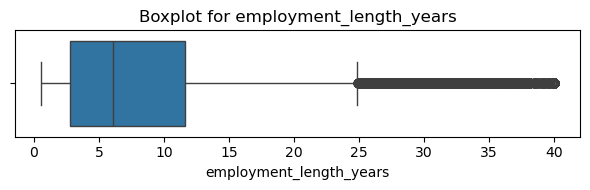

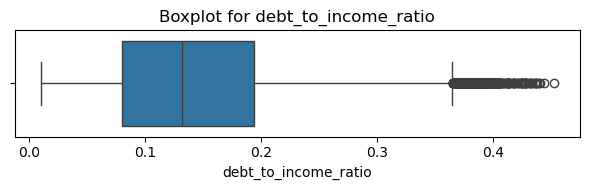

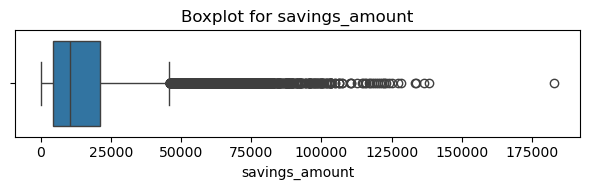

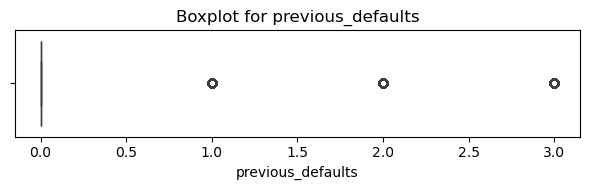

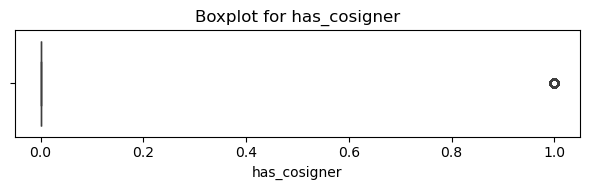

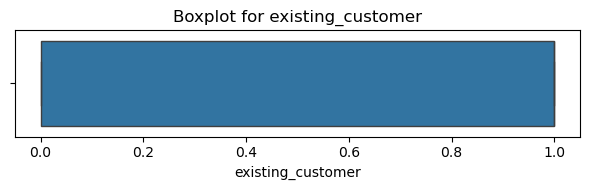

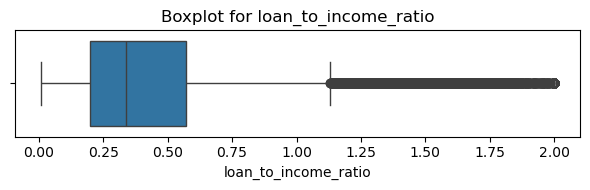

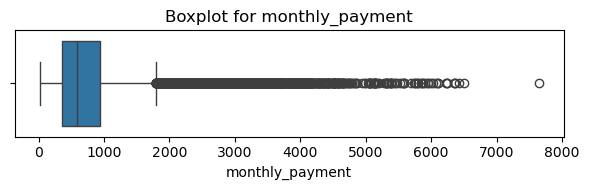

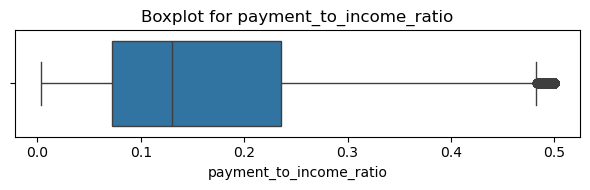

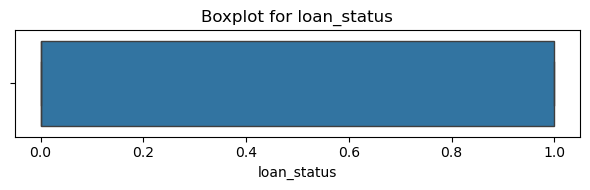

In [173]:
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("This are the numerical columns:", numerical_cols)

for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df_encoded[col])
    plt.title(f"Boxplot for {col}")
    plt.tight_layout()
    plt.show()

In [174]:
outlier_rows = pd.DataFrame(index=df_encoded.index)

for col in numerical_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_rows[col] = ~df_encoded[col].between(lower, upper)

outlier_rows['outlier_count'] = outlier_rows.sum(axis=1)

print(outlier_rows['outlier_count'].value_counts())
print("Number of rows with at least one outlier:", (outlier_rows['outlier_count'] > 0).sum())


outlier_count
0    27815
1    15443
2     4777
3     1355
4      479
5      113
6       18
Name: count, dtype: int64
Number of rows with at least one outlier: 22185


When we look at the boxplots, we can see that some variables—like income, loan amount, savings amount, and monthly payment—have a few really high values. This is pretty normal in financial data because some people have much bigger loans or higher incomes than others.
For other variables, like credit score, age, and loan term, everything looks clean and as expected.
Using the IQR method, we also found that about 44% of the rows in the dataset have at least one variable flagged as an outlier. In most cases, these outliers are due to just one or two variables, and only a very small number of rows (around 0.03% of the dataset) have extreme values across multiple variables.
At this point, I’m not removing any data because these high values seem realistic (for example, some clients are just richer or borrow more). But later, if we see that these extreme values are causing problems for the model—especially for logistic regression—we can cap them (for example, set a maximum value at the 99th percentile) to make sure they don’t have too much influence.

### Correlations 

                              age  ...  payment_to_income_ratio
age                      1.000000  ...                -0.004630
income                  -0.000418  ...                -0.486075
loan_amount             -0.001290  ...                 0.596812
loan_term_months         0.001456  ...                -0.444463
credit_score             0.006517  ...                -0.008652
employment_length_years  0.002524  ...                -0.003123
debt_to_income_ratio    -0.003578  ...                -0.005768
savings_amount           0.007751  ...                -0.004735
previous_defaults       -0.000988  ...                -0.003557
loan_to_income_ratio    -0.004904  ...                 0.819752
monthly_payment         -0.003644  ...                 0.743229
payment_to_income_ratio -0.004630  ...                 1.000000

[12 rows x 12 columns]


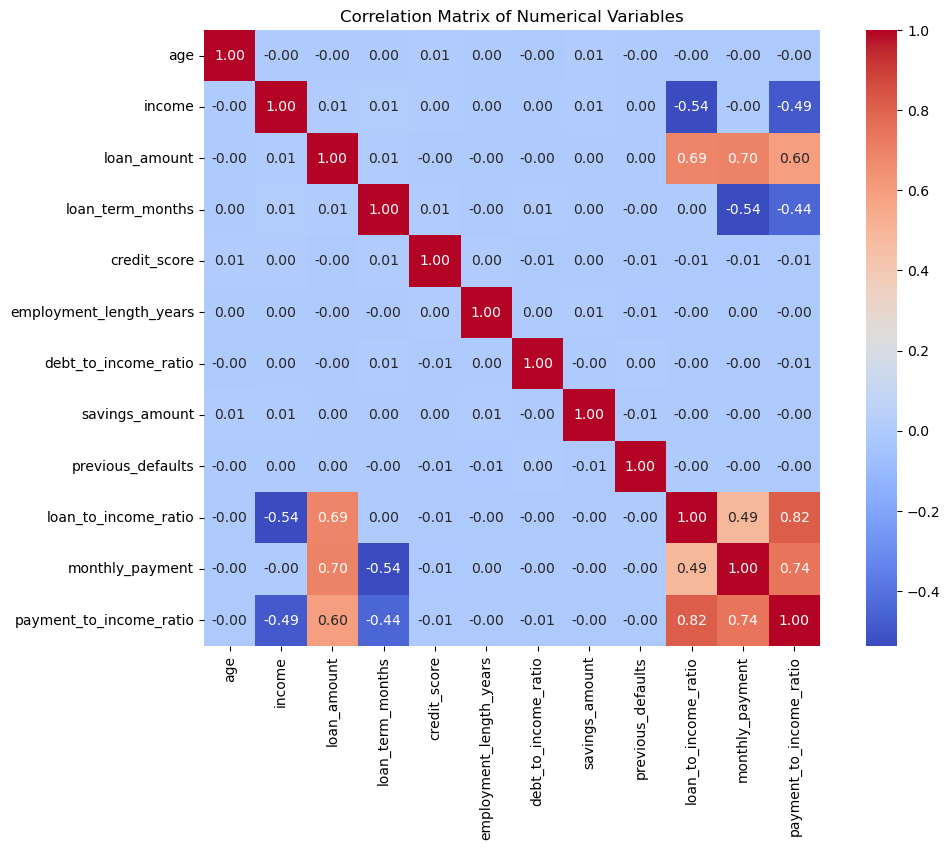

In [175]:
corr_matrix = df_encoded[numerical_cols_clean].corr()

print(corr_matrix)


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()


The correlation analysis shows that most variables are not strongly correlated, except for a few cases. In particular, loan_to_income_ratio, payment_to_income_ratio, and monthly_payment are highly correlated (above 0.8), which is logical because these variables are all related to the size of the loan relative to income. 

For the modeling part, especially with logistic regression, it may be wise to avoid including all three together to reduce multicollinearity risk. Other variables like age, credit_score, and loan_term_months show minimal correlation with others, which supports their independent value in prediction.

### Standardization 

We scal all the continuous numeric variables, which is important for logistic regression because it helps the model work better and keeps things balanced. For tree-based models like Random Forest, scaling isn’t needed, but we kept the scaled version so we can easily test different models later.

In [176]:
scaler = StandardScaler()

df_encoded_scaled = df_encoded.copy()
df_encoded_scaled[numerical_cols_clean] = scaler.fit_transform(df_encoded_scaled[numerical_cols_clean])

df_encoded_scaled[numerical_cols_clean].describe().round(2)




,age,income,loan_amount,loan_term_months,credit_score,employment_length_years,debt_to_income_ratio,savings_amount,previous_defaults,loan_to_income_ratio,monthly_payment,payment_to_income_ratio
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.70,-1.36,-1.65,-1.83,-2.71,-1.03,-1.66,-1.01,-0.38,-1.23,-1.18,-1.26
25%,-0.85,-0.75,-0.74,-0.91,-0.68,-0.73,-0.79,-0.71,-0.38,-0.69,-0.63,-0.75
50%,-0.00,-0.17,-0.19,-0.00,0.01,-0.30,-0.14,-0.31,-0.38,-0.29,-0.27,-0.32
75%,0.85,0.54,0.52,0.91,0.71,0.41,0.64,0.40,-0.38,0.36,0.29,0.46
max,1.70,8.10,8.28,1.83,1.84,4.10,3.87,11.22,5.09,4.38,11.12,2.41


### Skewness

We checked the skewness and plotted histograms for all numerical variables to see how their values are distributed. This helps us understand if variables are symmetric or skewed (for example, income tends to have a right-skewed distribution) and  decide later if we need to apply transformations like log scaling to improve model performance.


age
Skewness: 0.01


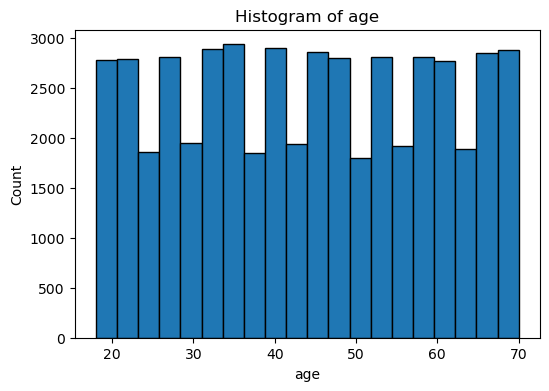


income
Skewness: 1.08


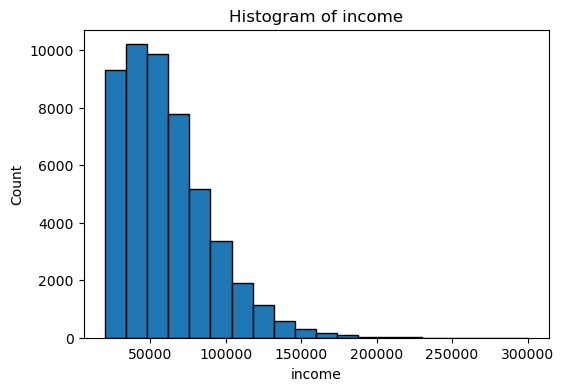


loan_amount
Skewness: 1.18


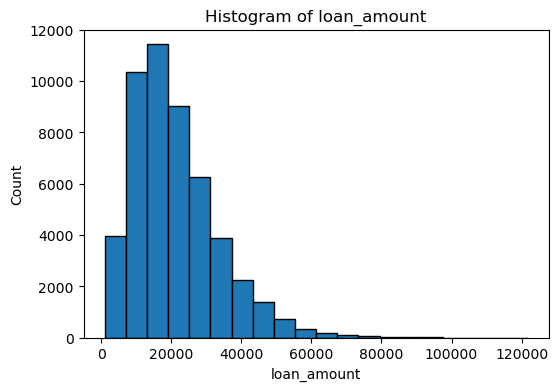


loan_term_months
Skewness: -0.0


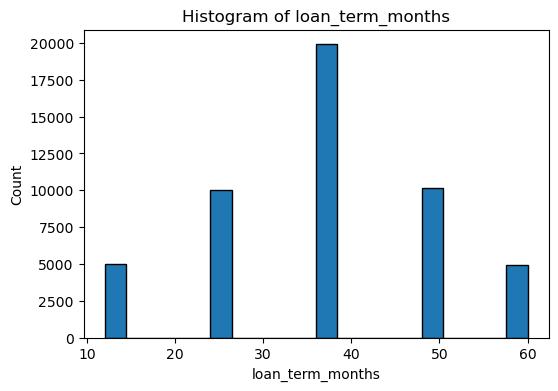


credit_score
Skewness: -0.15


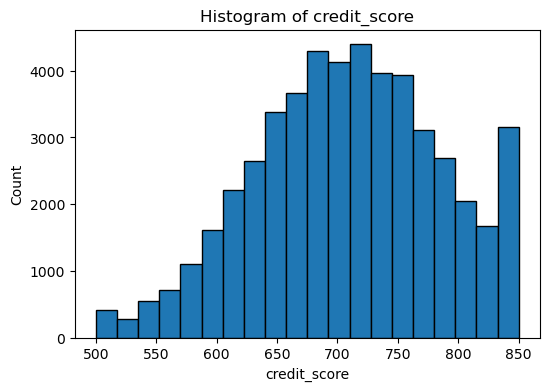


employment_length_years
Skewness: 1.64


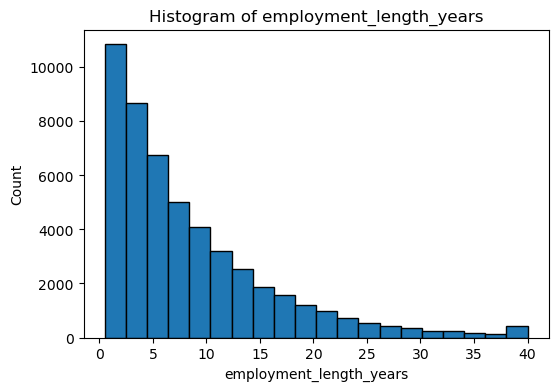


debt_to_income_ratio
Skewness: 0.6


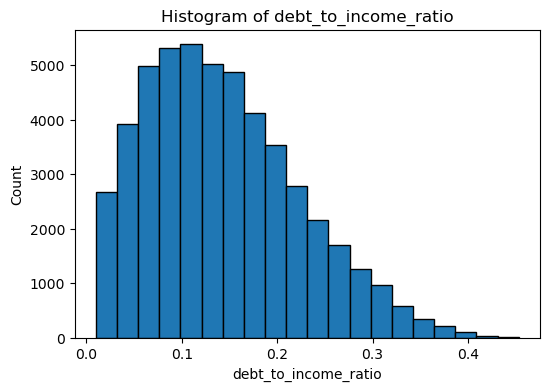


savings_amount
Skewness: 1.93


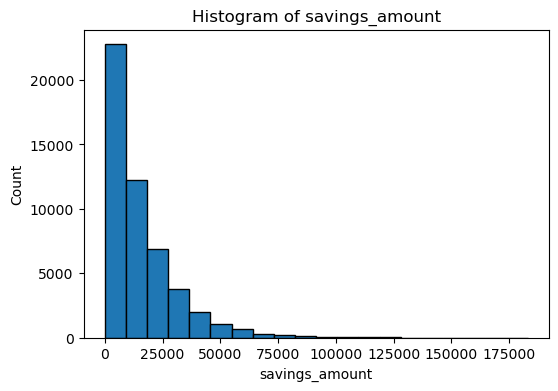


previous_defaults
Skewness: 2.91


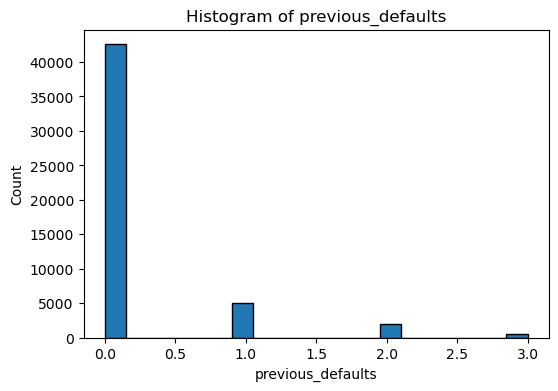


loan_to_income_ratio
Skewness: 1.81


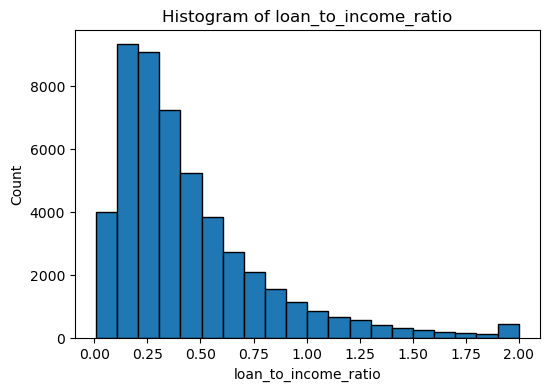


monthly_payment
Skewness: 2.61


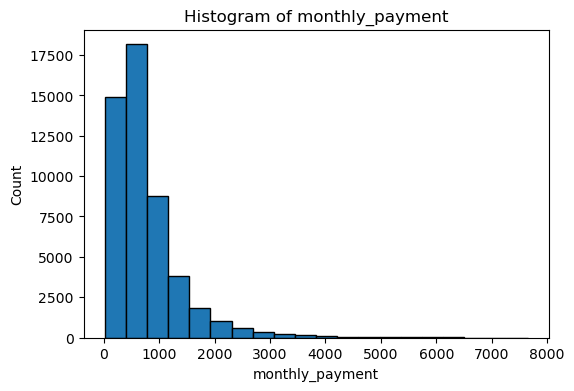


payment_to_income_ratio
Skewness: 1.13


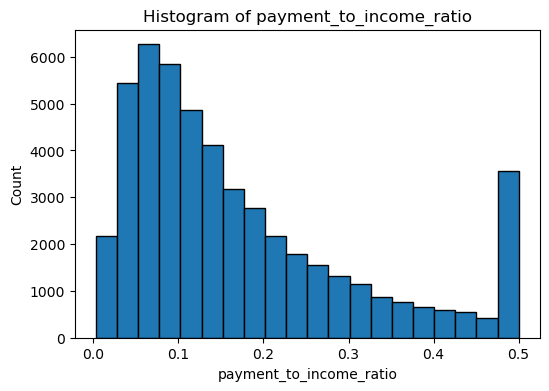

In [177]:
for feature in numerical_cols_clean:
    print(f"\n{feature}")
    print('Skewness:', round(df_encoded[feature].skew(), 2))

    plt.figure(figsize=(6, 4))
    plt.hist(df_encoded[feature], bins=20, edgecolor='k')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

Most numeric variables look fine, but a few (like income, loan amount, and savings) are very skewed because some people have much bigger loans or higher incomes. This is normal, but we might consider log-transforming these in the future if it helps the model work better. Other variables, like credit score and age, look clean and don’t need changes.

### Checking balance

We checked the distribution of the dependent variable (loan_status). The dataset has around 62% repaid loans and 38% defaulted loans. This shows a mild class imbalance but not extreme, just something to consider during modeling. To handle this, we could use options like class_weight='balanced' in logistic regression or rely on tree-based models, which handle imbalance more robustly. At this point, no additional resampling (like SMOTE) has been applied.

Class Counts:
 loan_status
repaid     31216
default    18784
Name: count, dtype: int64

Class Percentages:
 loan_status
repaid     0.62
default    0.38
Name: proportion, dtype: float64


/var/folders/xk/099rblcn2k99szyfbf_t878r0000gn/T/ipykernel_1419/1811553225.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df_clean, palette='pastel')


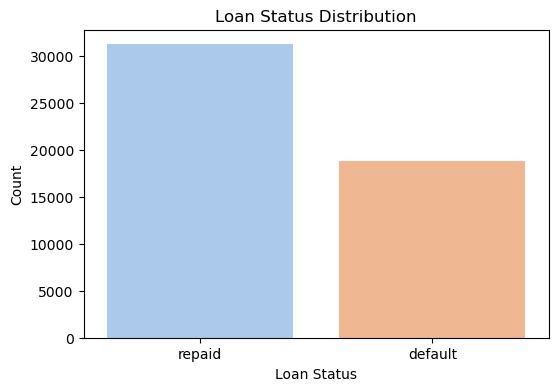

In [178]:
class_counts = df_clean['loan_status'].value_counts()
class_percentages = df_clean['loan_status'].value_counts(normalize=True).round(2)

print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", class_percentages)

plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df_clean, palette='pastel')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()


## 2. Modeling 

In [179]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


### Train-Test Split

We now prepare the dataset for modeling. We define our feature set `X` by dropping the target column (`loan_status`), and keep the target variable `y`.

To fairly evaluate the models, we split the data into a training set (80%) and a testing set (20%).  
We use stratified sampling to make sure the class proportions (default vs. repaid) are preserved in both sets.

In [180]:
X = df_encoded_scaled.drop(columns='loan_status')
y = df_encoded_scaled['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train value counts:")
print(y_train.value_counts(normalize=True))
print("\ny_test value counts:")
print(y_test.value_counts(normalize=True))

X_train shape: (40000, 29)
X_test shape: (10000, 29)
y_train value counts:
loan_status
0    0.624325
1    0.375675
Name: proportion, dtype: float64

y_test value counts:
loan_status
0    0.6243
1    0.3757
Name: proportion, dtype: float64


After splitting, both the training and testing sets maintain the same proportion of defaulted loans (about 38%). This ensures that our evaluation will not be biased due to class imbalance, which is especially important when working with financial defaults.

We now move forward to train our first model.


### Logistic Regression (Baseline Model)

We start with a logistic regression model as our baseline to predict the probability of default. Although it may not perform as well as more complex models, it provides a useful benchmark to compare with future models.

We train it on the scaled training set and evaluate its performance on the test set.


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'classifier__C': 0.1, 'classifier__max_iter': 500, 'classifier__penalty': 'l1'}

Accuracy:  0.7699
Precision: 0.7259
Recall:    0.6226
F1 Score:  0.6703
AUC Score: 0.8383

Confusion Matrix:
 [[5360  883]
 [1418 2339]]


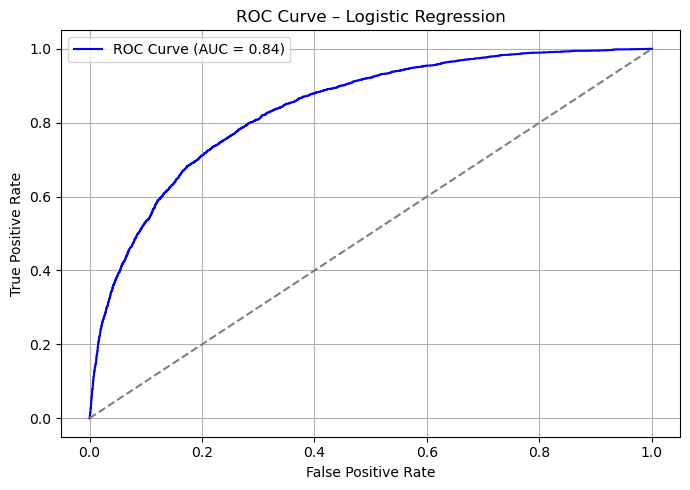

/var/folders/xk/099rblcn2k99szyfbf_t878r0000gn/T/ipykernel_1419/1210543434.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


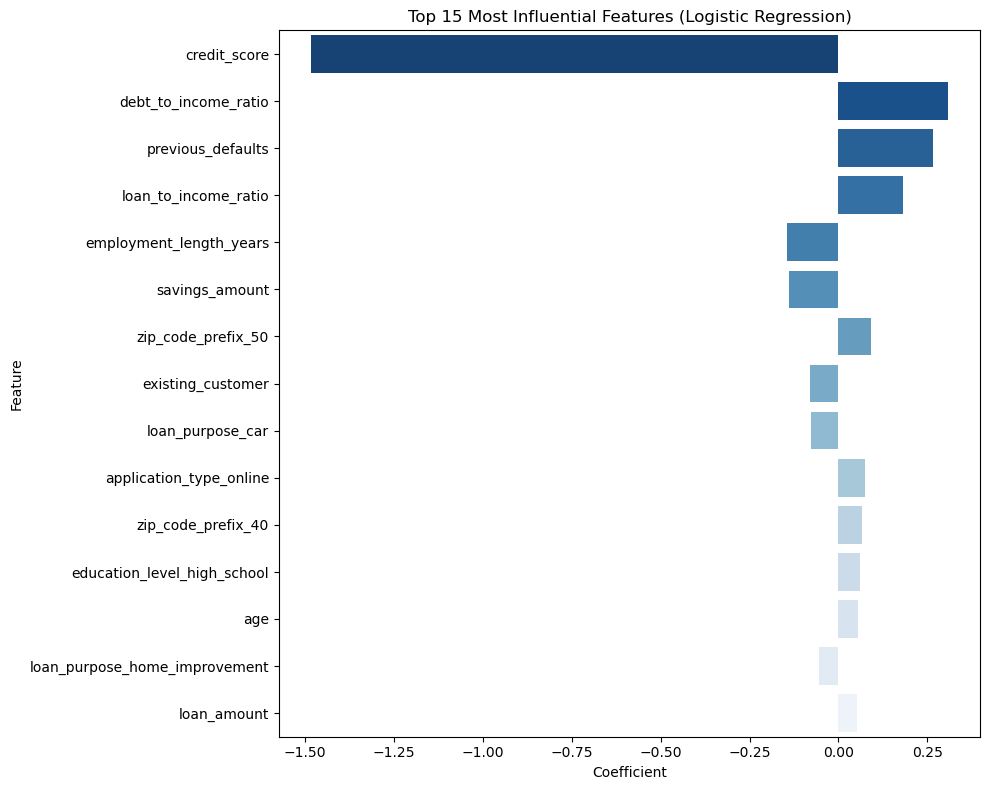

In [181]:
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear'))  # 'liblinear' supports both L1 and L2
])

# Define parameter grid for regularization tuning
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],        # Regularization strength
    'classifier__penalty': ['l1', 'l2'],        # Type of penalty
    'classifier__max_iter': [500]
}

# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with ROC AUC scoring
grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Train the model
grid_search.fit(X_train, y_train)
best_lr_model = grid_search.best_estimator_

# Predict and score
y_pred = best_lr_model.predict(X_test)
y_proba = best_lr_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
conf_mat = confusion_matrix(y_test, y_pred)

# Print metrics
print("Best parameters:", grid_search.best_params_)
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC Score: {auc:.4f}")
print("\nConfusion Matrix:\n", conf_mat)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature importance from coefficients
coefs = best_lr_model.named_steps['classifier'].coef_[0]
features = X.columns

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Plot top features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Coefficient', y='Feature',
    data=coef_df.head(15),
    palette='Blues_r'
)
plt.title('Top 15 Most Influential Features (Logistic Regression)')
plt.tight_layout()
plt.show()


We trained a regularized logistic regression model with hyperparameter tuning using 5-fold cross-validation, optimizing for AUC. The model achieved values that suggest the model balances well between identifying true defaults and avoiding false alarms. The AUC score is particularly encouraging, indicating strong ability to discriminate between repaid and defaulted loans.

The confusion matrix reveals that:

2,339 defaults were correctly predicted (true positives)
1,418 defaults were missed (false negatives)
883 loans were incorrectly predicted as default (false positives)

This tradeoff between false negatives and false positives is central in credit risk settings, where the cost of misclassification can be asymmetrical depending on the institution’s risk appetite.

To improve interpretability and simplify the model, we retrain a logistic regression using only the 10 most influential features identified from the full model. These are selected based on the absolute value of their coefficients, which reflect their contribution to predicting default.

This step is especially relevant in financial contexts, where:
- Model transparency is critical for compliance and decision-making.
- Simplicity reduces the risk of overfitting and improves robustness.
- Ease of communication with non-technical stakeholders (e.g., credit officers) is important.

We evaluate this smaller model using the same metrics (accuracy, precision, recall, F1, and AUC) and compare its performance to the full model. A similar AUC and F1 score would suggest that the top 10 features capture most of the predictive power, making the simpler model a strong alternative.

We also plot a new ROC curve to assess the classifier's ability to distinguish between defaulted and repaid loans using only these features.



🔍 Logistic Regression (Top 10 features only)
Accuracy: 0.7689
Precision: 0.724
Recall: 0.622
F1 Score: 0.6691
AUC Score: 0.8363


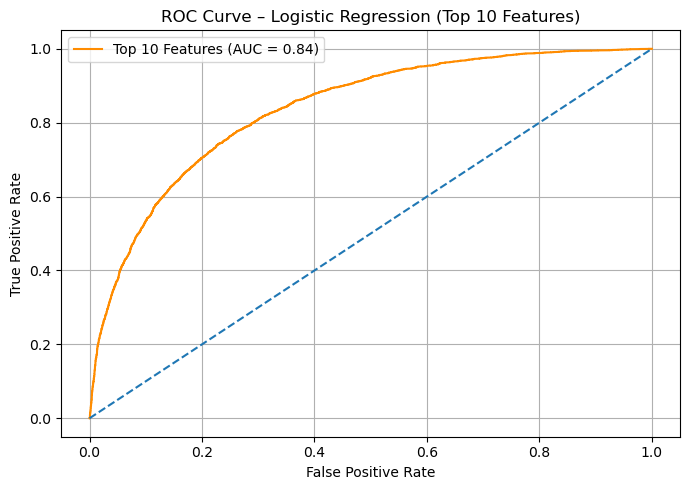

In [182]:
top_features = coef_df.head(10)['Feature'].tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Step 3: Train a simpler logistic regression model
logreg_simple = LogisticRegression(max_iter=500, solver='liblinear', penalty='l1', C=0.1)
logreg_simple.fit(X_train_top, y_train)

# Step 4: Predict and evaluate
y_pred_simple = logreg_simple.predict(X_test_top)
y_proba_simple = logreg_simple.predict_proba(X_test_top)[:, 1]

print("\n🔍 Logistic Regression (Top 10 features only)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_simple), 4))
print("Precision:", round(precision_score(y_test, y_pred_simple), 4))
print("Recall:", round(recall_score(y_test, y_pred_simple), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_simple), 4))
print("AUC Score:", round(roc_auc_score(y_test, y_proba_simple), 4))

# Step 5: Plot ROC curve for the simpler model
fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_simple)
plt.figure(figsize=(7, 5))
plt.plot(fpr_s, tpr_s, label='Top 10 Features (AUC = {:.2f})'.format(roc_auc_score(y_test, y_proba_simple)), color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression (Top 10 Features)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


These metrics are nearly identical to the full-feature model, which means that we retain most of the predictive power, the model becomes more interpretable, easier to justify in a financial context and it’s more robust, as it avoids relying on potentially noisy or redundant features.
The ROC curve shows excellent class separation. With an AUC of 0.84, the model has strong ability to distinguish between defaulters and non-defaulters even with reduced inputs. This validates that the selected features carry the bulk of the information needed.

In [183]:
X_train_numeric = pd.DataFrame(X_train, columns=X.columns).astype(float)
X_train_sm = sm.add_constant(X_train_numeric)
y_train_sm = y_train.astype(float)

# Fit logistic regression using statsmodels
logit_model = sm.Logit(y_train_sm, X_train_sm)
result = logit_model.fit()

# Display summary
print(result.summary())

# Extract and display confidence intervals and p-values
conf_int = result.conf_int()
conf_int.columns = ['2.5%', '97.5%']
conf_int['Coefficient'] = result.params
conf_int['p-value'] = result.pvalues
conf_int_sorted = conf_int.sort_values(by='p-value')

# Show top 10 most significant features
conf_int_sorted.head(10)

Optimization terminated successfully.
         Current function value: 0.486438
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                40000
Model:                          Logit   Df Residuals:                    39970
Method:                           MLE   Df Model:                           29
Date:                Sun, 11 May 2025   Pseudo R-squ.:                  0.2651
Time:                        22:31:27   Log-Likelihood:                -19458.
converged:                       True   LL-Null:                       -26476.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -0.7423      0.055    -13.488  

,2.5%,97.5%,Coefficient,p-value
credit_score,-1.525212,-1.460063,-1.492637,0.000000e+00
debt_to_income_ratio,0.286735,0.336213,0.311474,1.892871e-134
previous_defaults,0.242105,0.290292,0.266199,5.474966e-104
const,-0.850212,-0.634470,-0.742341,1.840964e-41
employment_length_years,-0.171974,-0.121973,-0.146974,1.019400e-30
savings_amount,-0.165528,-0.114986,-0.140257,1.467711e-27
existing_customer,-0.219624,-0.119892,-0.169758,2.519202e-11
zip_code_prefix_50,0.225401,0.422972,0.324187,1.258856e-10
application_type_online,0.105240,0.215491,0.160366,1.186120e-08
loan_to_income_ratio,0.125696,0.267627,0.196661,5.588843e-08


This output confirms that not all top features from the scikit-learn model are statistically significant — a reminder that coefficient magnitude doesn't always mean significance. The confidence intervals also allow you to assess estimation uncertainty, which is important for real-world deployment.

The lift curve shows how much better your model is at identifying defaults than random guessing. It’s widely used in credit risk to see how concentrated true positives are in the top predicted scores.

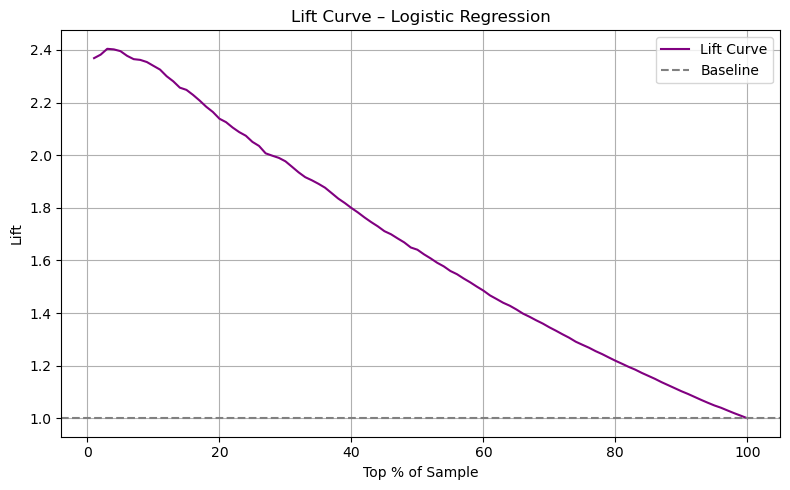

In [184]:
def lift_at_percentile(y_true, y_scores, percentile):
    cutoff_index = int(len(y_scores) * percentile)
    sorted_indices = np.argsort(y_scores)[::-1]
    top_indices = sorted_indices[:cutoff_index]
    positives_in_top = np.sum(y_true.iloc[top_indices])
    baseline_positive_rate = np.mean(y_true)
    lift = positives_in_top / (cutoff_index * baseline_positive_rate)
    return lift

# Compute lift at each percentile
lifts = [lift_at_percentile(y_test.reset_index(drop=True), pd.Series(y_proba), p/100) for p in range(1, 101)]

# Plot lift curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), lifts, label='Lift Curve', color='purple')
plt.axhline(1, linestyle='--', color='gray', label='Baseline')
plt.xlabel('Top % of Sample')
plt.ylabel('Lift')
plt.title('Lift Curve – Logistic Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The lift curve shows that the model is over 2.4× more effective than random selection at identifying defaulters in the top-risk group, confirming strong discriminatory power.

Before fully trusting a predictive model, it's important to check whether it performs consistently across key subgroups. For example, a model that works well for high-income clients but poorly for low-income ones may introduce bias or be unsuitable in some financial contexts. In this next part, we evaluate how logistic regression performs across income levels, education backgrounds, and loan purposes.

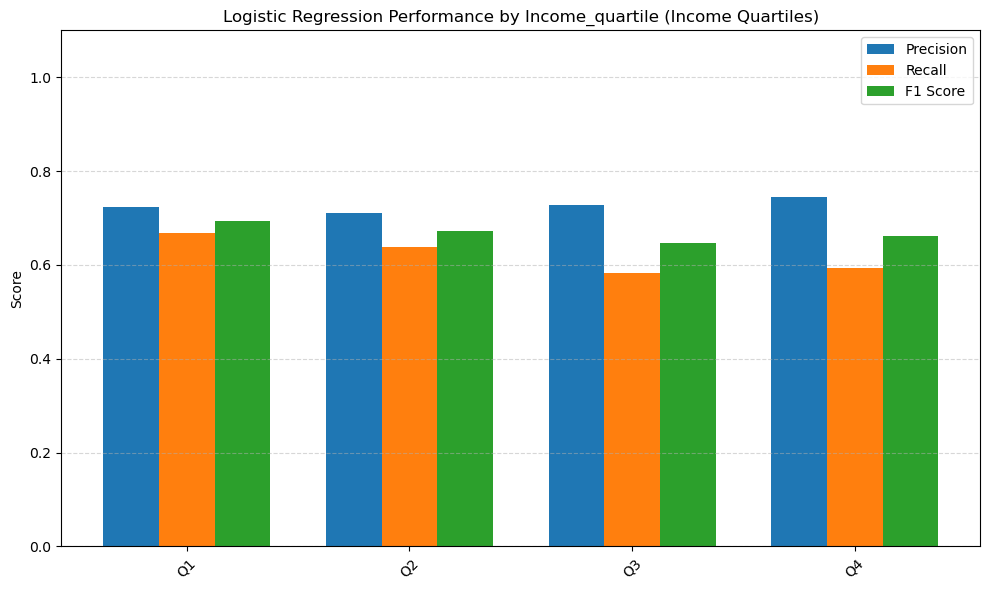

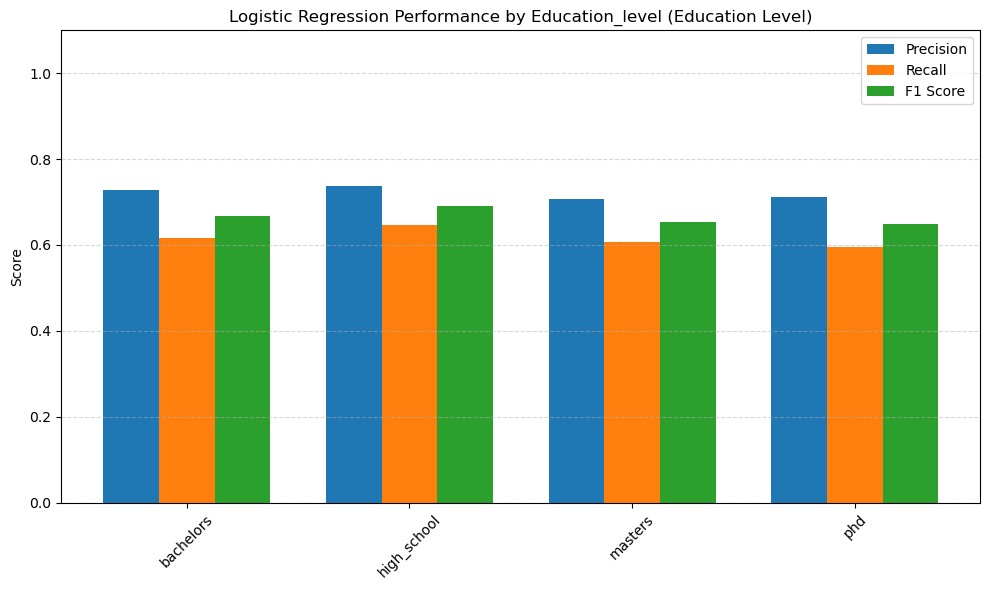

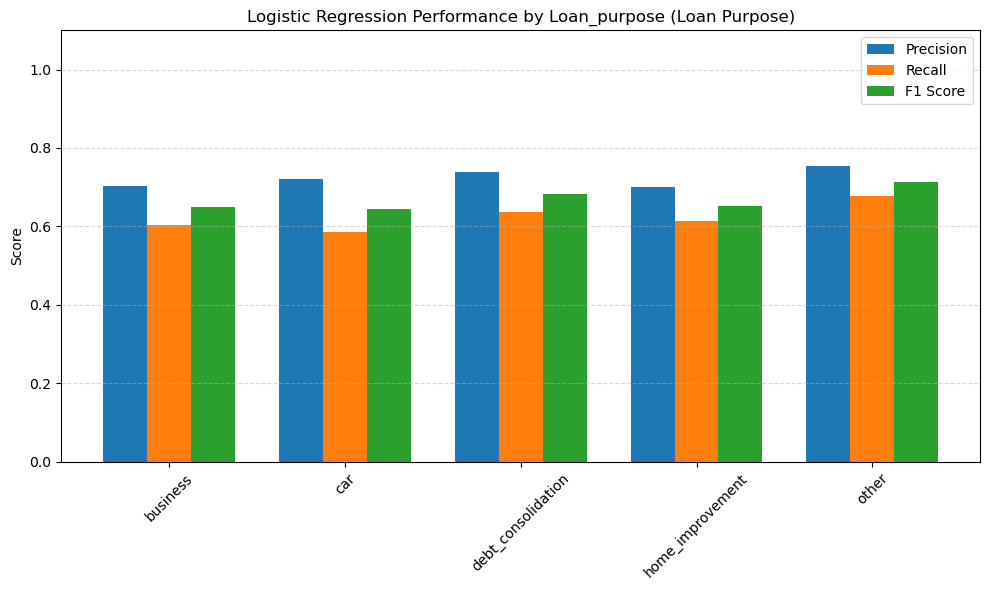

In [185]:


def plot_segmented_scores(feature_name, X_data, y_true, y_pred, title_suffix=""):
    segments = sorted(X_data[feature_name].unique())
    precisions, recalls, f1s = [], [], []

    for val in segments:
        idx = X_data[feature_name] == val
        y_true_seg = y_true[idx]
        y_pred_seg = y_pred[idx]

        if sum(y_true_seg) == 0 or sum(y_pred_seg) == 0:
            precisions.append(np.nan)
            recalls.append(np.nan)
            f1s.append(np.nan)
            continue

        precisions.append(precision_score(y_true_seg, y_pred_seg))
        recalls.append(recall_score(y_true_seg, y_pred_seg))
        f1s.append(f1_score(y_true_seg, y_pred_seg))

    # Plot
    x = np.arange(len(segments))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, precisions, width, label='Precision')
    plt.bar(x, recalls, width, label='Recall')
    plt.bar(x + width, f1s, width, label='F1 Score')
    plt.xticks(x, segments, rotation=45)
    plt.title(f"Logistic Regression Performance by {feature_name.capitalize()} {title_suffix}")
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.legend()
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
    

# Income quartiles (already created in previous step)
plot_segmented_scores('income_quartile', X_test_segmented, y_test, y_pred, "(Income Quartiles)")

# Education
plot_segmented_scores('education_level', X_test_segmented, y_test, y_pred, "(Education Level)")

# Loan Purpose
plot_segmented_scores('loan_purpose', X_test_segmented, y_test, y_pred, "(Loan Purpose)")


The model performs consistently across most education levels and income groups, with slightly higher precision for high-income and high school–educated individuals. Performance by loan purpose shows more variation: predictions are strongest for debt consolidation and weakest for car or business loans, possibly due to more diverse applicant profiles. Overall, there are no alarming disparities, but some segments (e.g., Q3 income or business loans) may benefit from deeper analysis or tailored features.

### Random Forest

We now train a Random Forest classifier, which captures non-linear relationships and interactions between features. It is robust to outliers and multicollinearity, making it a strong non-parametric benchmark.
We tune hyperparameters using cross-validation, evaluate classification performance, visualize the ROC curve and lift curve, and interpret feature importance based on impurity reduction.


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
Accuracy: 0.7683
Precision: 0.726
Recall: 0.6157
F1 Score: 0.6663
AUC: 0.8313

Confusion Matrix:
 [[5370  873]
 [1444 2313]]


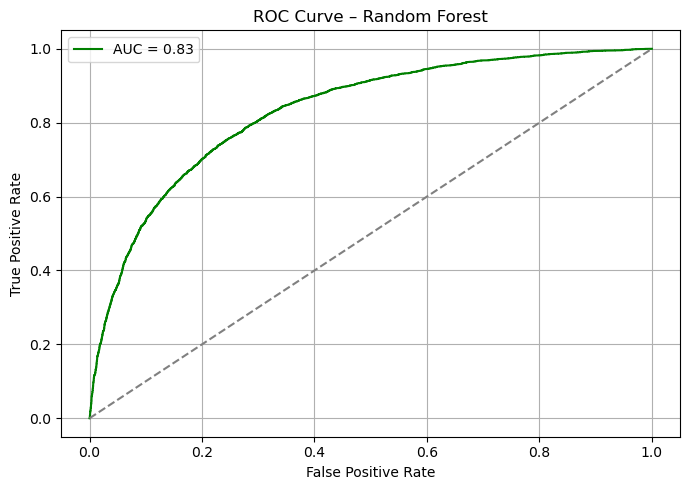

/var/folders/xk/099rblcn2k99szyfbf_t878r0000gn/T/ipykernel_1419/3483569155.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df, palette='Greens_r')


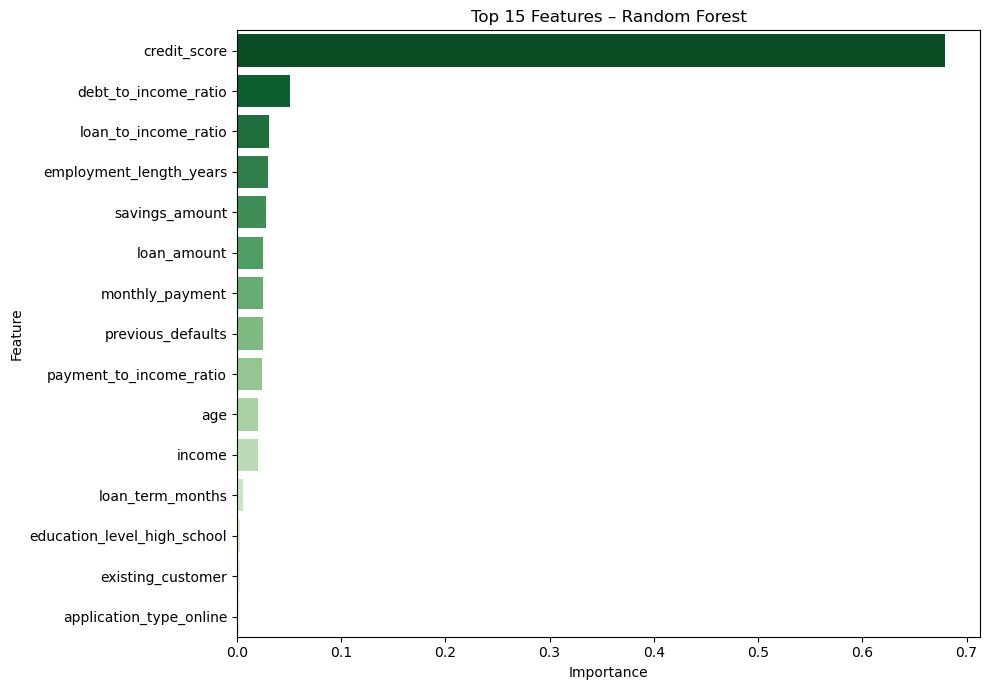

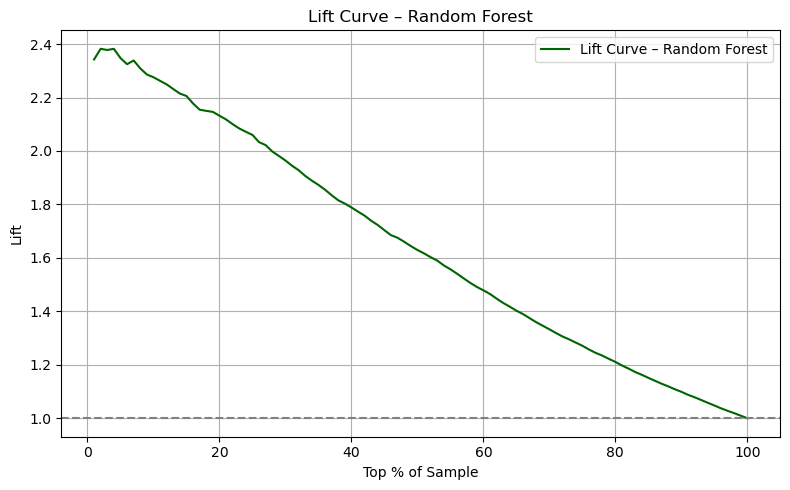

In [186]:
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100],
    'max_depth': [5, 10, 20],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

# 2. Best model
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

# 3. Evaluation
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# 4. ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_auc_score(y_test, y_proba_rf):.2f}', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Feature Importance Plot
importances = rf_best.feature_importances_
feature_names = X_train.columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='Greens_r')
plt.title('Top 15 Features – Random Forest')
plt.tight_layout()
plt.show()

# 6. Lift Curve
def lift_at_percentile(y_true, y_scores, percentile):
    cutoff = int(len(y_scores) * percentile)
    sorted_idx = np.argsort(y_scores)[::-1]
    top_idx = sorted_idx[:cutoff]
    lift = y_true.iloc[top_idx].sum() / (cutoff * y_true.mean())
    return lift

lifts_rf = [lift_at_percentile(y_test.reset_index(drop=True), pd.Series(y_proba_rf), p/100) for p in range(1, 101)]

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), lifts_rf, label='Lift Curve – Random Forest', color='darkgreen')
plt.axhline(1, linestyle='--', color='gray')
plt.xlabel('Top % of Sample')
plt.ylabel('Lift')
plt.title('Lift Curve – Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Random Forest model delivers robust predictive performance, achieving an accuracy of 76.8%, precision of 72.6%, recall of 61.7%, F1 score of 66.6%, and an AUC of 0.8313, nearly matching the logistic regression's results. The ROC curve confirms strong discriminatory ability, while the lift curve shows that the model effectively prioritizes high-risk (default-prone) clients. In terms of feature importance, credit score is by far the most decisive variable, followed by debt-to-income ratio and loan-to-income ratio, suggesting that financial pressure indicators remain central even in a non-linear setting. Notably, Random Forests capture more complex patterns and interactions than logistic regression, making them a valuable benchmark in this analysis.

### Gradient Boosting

We now train a third model implementing gradient boosting. It is particularly well-suited for large tabular datasets and offers strong predictive power. This model builds an ensemble of decision trees sequentially, correcting the mistakes of previous trees. It handles missing values and categorical features more effectively than many other models and typically provides better performance than Random Forest.

We'll use cross-validation and grid search to tune hyperparameters and evaluate the model using ROC AUC, lift curves, and feature importances.


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Gradient Boosting Results
Best parameters: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'max_iter': 100}
Accuracy:  0.7688
Precision: 0.7227
Recall:    0.6242
F1 Score:  0.6698
AUC Score: 0.8357
Confusion Matrix:
 [[5343  900]
 [1412 2345]]


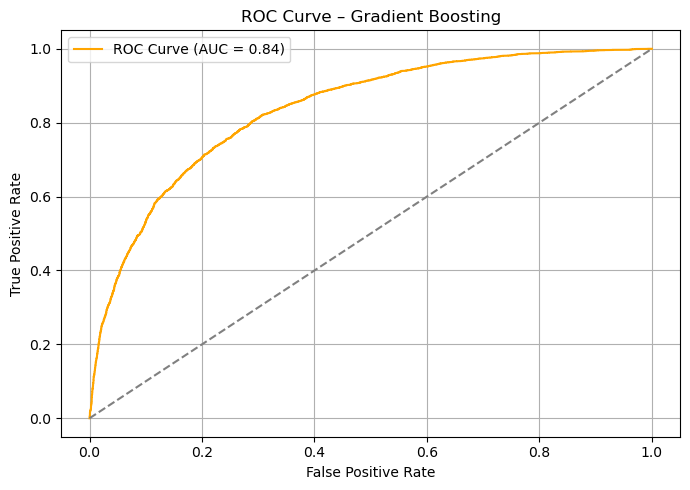

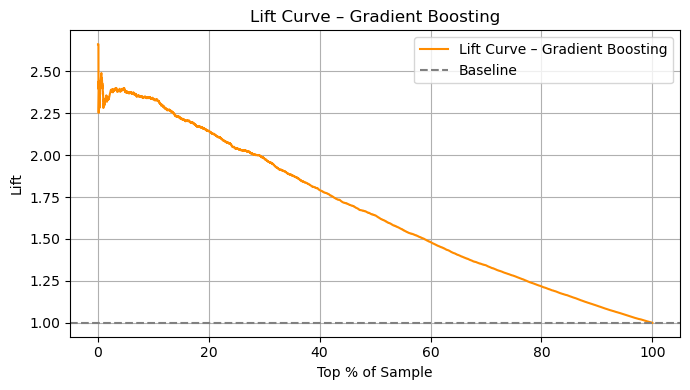

/var/folders/xk/099rblcn2k99szyfbf_t878r0000gn/T/ipykernel_1419/1868664320.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_df.head(15), x='Importance', y='Feature', palette='Oranges_r')


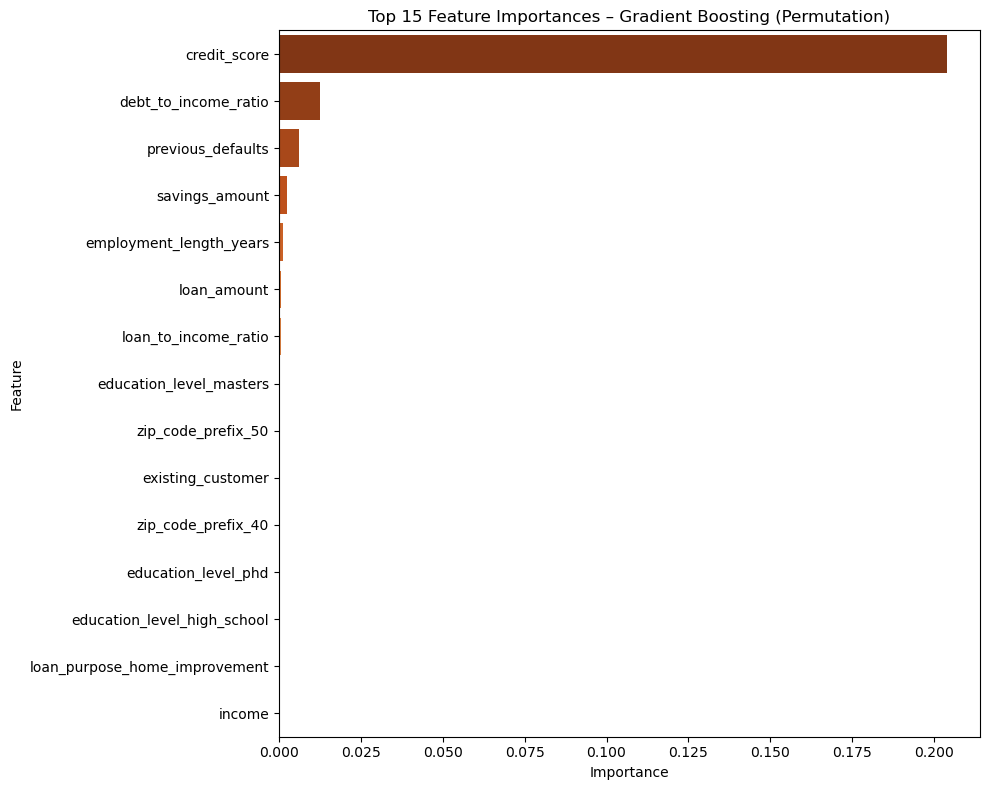

In [188]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = HistGradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'learning_rate': [0.01, 0.1],
    'max_iter': [100, 200],
    'max_depth': [None, 6, 10],
    'l2_regularization': [0.0, 1.0]
}

# Grid search with stratified cross-validation
grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search_gb.fit(X_train, y_train)
best_gb_model = grid_search_gb.best_estimator_

# Predict
y_pred_gb = best_gb_model.predict(X_test)
y_proba_gb = best_gb_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)
conf_gb = confusion_matrix(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("Best parameters:", grid_search_gb.best_params_)
print(f"Accuracy:  {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"Recall:    {rec_gb:.4f}")
print(f"F1 Score:  {f1_gb:.4f}")
print(f"AUC Score: {auc_gb:.4f}")
print("Confusion Matrix:\n", conf_gb)

# ROC Curve
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
plt.figure(figsize=(7, 5))
plt.plot(fpr_gb, tpr_gb, label=f'ROC Curve (AUC = {auc_gb:.2f})', color='orange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve – Gradient Boosting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Lift curve
def compute_lift(y_true, y_scores):
    df = pd.DataFrame({'y_true': y_true, 'y_scores': y_scores})
    df = df.sort_values('y_scores', ascending=False)
    df['cumulative_positives'] = df['y_true'].cumsum()
    df['percentage_sample'] = np.arange(1, len(df)+1) / len(df)
    baseline = df['y_true'].sum() / len(df)
    df['lift'] = df['cumulative_positives'] / (df['percentage_sample'] * len(df) * baseline)
    return df['percentage_sample'], df['lift']

x_lift, y_lift = compute_lift(y_test, y_proba_gb)

plt.figure(figsize=(7, 4))
plt.plot(x_lift * 100, y_lift, label='Lift Curve – Gradient Boosting', color='darkorange')
plt.axhline(1, color='gray', linestyle='--', label='Baseline')
plt.xlabel('Top % of Sample')
plt.ylabel('Lift')
plt.title('Lift Curve – Gradient Boosting')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.inspection import permutation_importance

# Compute permutation importances
perm_importance = permutation_importance(
    best_gb_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Create DataFrame of importances
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10, 8))
sns.barplot(data=perm_df.head(15), x='Importance', y='Feature', palette='Oranges_r')
plt.title('Top 15 Feature Importances – Gradient Boosting (Permutation)')
plt.tight_layout()
plt.show()



The gradient boosting model achieved strong performance, with an accuracy of 76.9% and an AUC of 0.84, slightly outperforming the random forest model on recall and F1 score. The ROC curve confirms solid discriminative power, while the lift curve indicates the model is particularly effective at ranking high-risk clients — with over 2.5x lift in the top decile. The permutation-based feature importance reveals that credit_score dominates the model's predictions, followed distantly by debt_to_income_ratio and previous_defaults. This highlights that while the model is highly predictive, it may rely heavily on a few key features.

### Decision Tree

As our final model, we train a Decision Tree classifier. While typically less powerful than ensemble methods like Random Forest or Gradient Boosting, a decision tree offers full interpretability and allows us to understand the basic logic of splits. 

We tune key hyperparameters (depth and split size), evaluate performance, plot the ROC and lift curve, and visualize the most important features.


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Accuracy:  0.7595
Precision: 0.7002
Recall:    0.6292
F1 Score:  0.6628
AUC Score: 0.8208

Confusion Matrix:
 [[5231 1012]
 [1393 2364]]


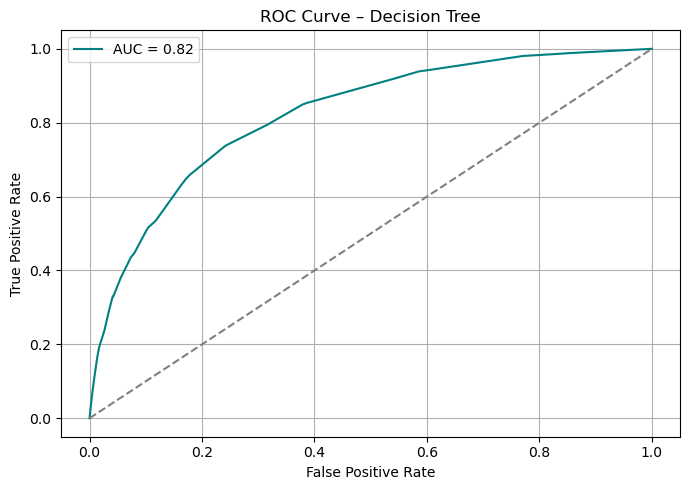

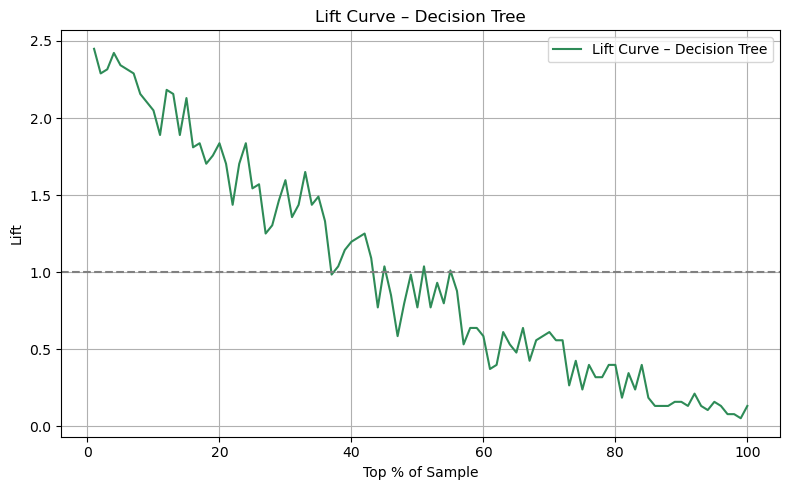

/var/folders/xk/099rblcn2k99szyfbf_t878r0000gn/T/ipykernel_1419/2750765590.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features.values[:15], y=features.index[:15], palette='BuGn_r')


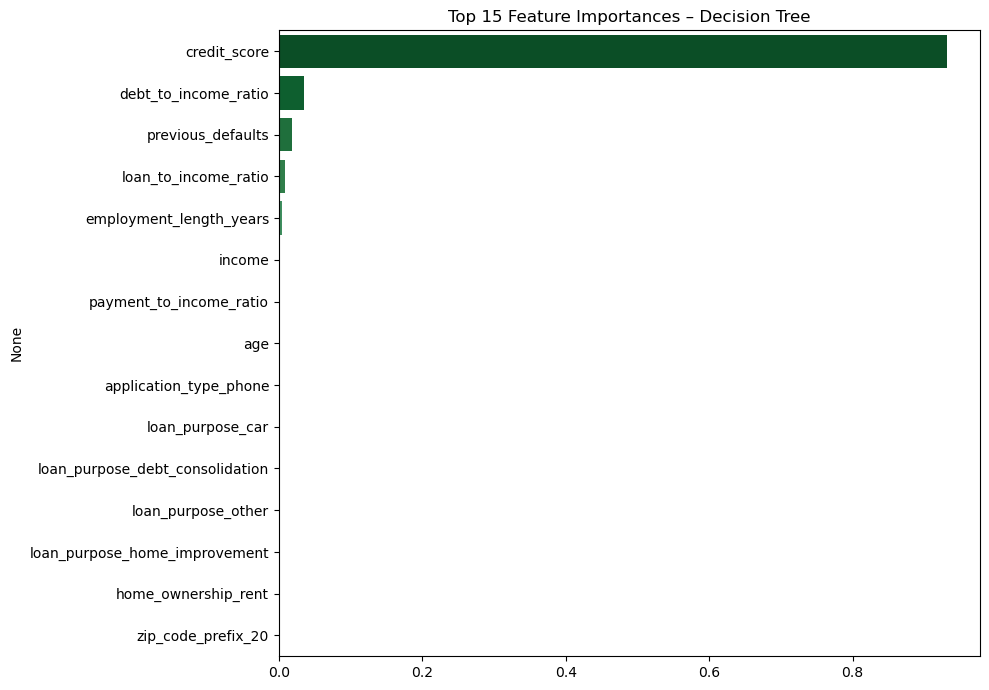

In [189]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold


tree_param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

tree_model = DecisionTreeClassifier(random_state=42)

tree_grid = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

tree_grid.fit(X_train, y_train)
best_tree_model = tree_grid.best_estimator_

# Predictions
y_pred_tree = best_tree_model.predict(X_test)
y_proba_tree = best_tree_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Best parameters:", tree_grid.best_params_)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tree):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_tree):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_proba_tree):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

# ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
plt.figure(figsize=(7, 5))
plt.plot(fpr_tree, tpr_tree, label='AUC = {:.2f}'.format(roc_auc_score(y_test, y_proba_tree)), color='teal')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve – Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Lift Curve
def lift_curve(y_scores, y_true, buckets=100):
    data = pd.DataFrame({'score': y_scores, 'true': y_true})
    data.sort_values('score', ascending=False, inplace=True)
    data['bucket'] = pd.qcut(data['score'].rank(method='first'), buckets, labels=False)
    lift = data.groupby('bucket')['true'].mean() / data['true'].mean()
    return lift[::-1].values  # reverse for top % first

lift_vals = lift_curve(y_proba_tree, y_test)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), lift_vals, label='Lift Curve – Decision Tree', color='seagreen')
plt.axhline(1, linestyle='--', color='gray')
plt.xlabel('Top % of Sample')
plt.ylabel('Lift')
plt.title('Lift Curve – Decision Tree')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance
importances = best_tree_model.feature_importances_
features = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=features.values[:15], y=features.index[:15], palette='BuGn_r')
plt.title("Top 15 Feature Importances – Decision Tree")
plt.tight_layout()
plt.show()


The Decision Tree achieved an accuracy of 0.760, precision of 0.700, recall of 0.692, and AUC of 0.820. These values indicate slightly weaker performance compared to ensemble models like Random Forest or Gradient Boosting. The ROC curve is well above the diagonal, confirming solid classification ability, but the lift curve is more volatile, reflecting a model that struggles with ranking the top-risk individuals as consistently as boosted ensembles. Feature importance shows a sharp drop-off after the first few variables — especially credit_score, which dominates. This confirms that while the tree captures some signal, it tends to over-rely on a few features, making it less robust overall.

Another idea could be neural netwroks. 

## 3. Comparision 

In [191]:
# Logistic Regression
accuracy_logreg = 0.769
precision_logreg = 0.7259
recall_logreg = 0.6226
f1_logreg = 0.6703
auc_logreg = 0.8383

# Random Forest
accuracy_rf = 0.768
precision_rf = 0.7262
recall_rf = 0.6175
f1_rf = 0.6663
auc_rf = 0.8313

# Gradient Boosting
accuracy_gb = 0.7688
precision_gb = 0.722
recall_gb = 0.6422
f1_gb = 0.6698
auc_gb = 0.8357

# Decision Tree
accuracy_tree = 0.7595
precision_tree = 0.7002
recall_tree = 0.6292
f1_tree = 0.6628
auc_tree = 0.8208

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.7690,0.7259,0.6226,0.6703,0.8383
1,Random Forest,0.7680,0.7262,0.6175,0.6663,0.8313
2,Gradient Boosting,0.7688,0.7220,0.6422,0.6698,0.8357
3,Decision Tree,0.7595,0.7002,0.6292,0.6628,0.8208


<Figure size 1200x600 with 0 Axes>

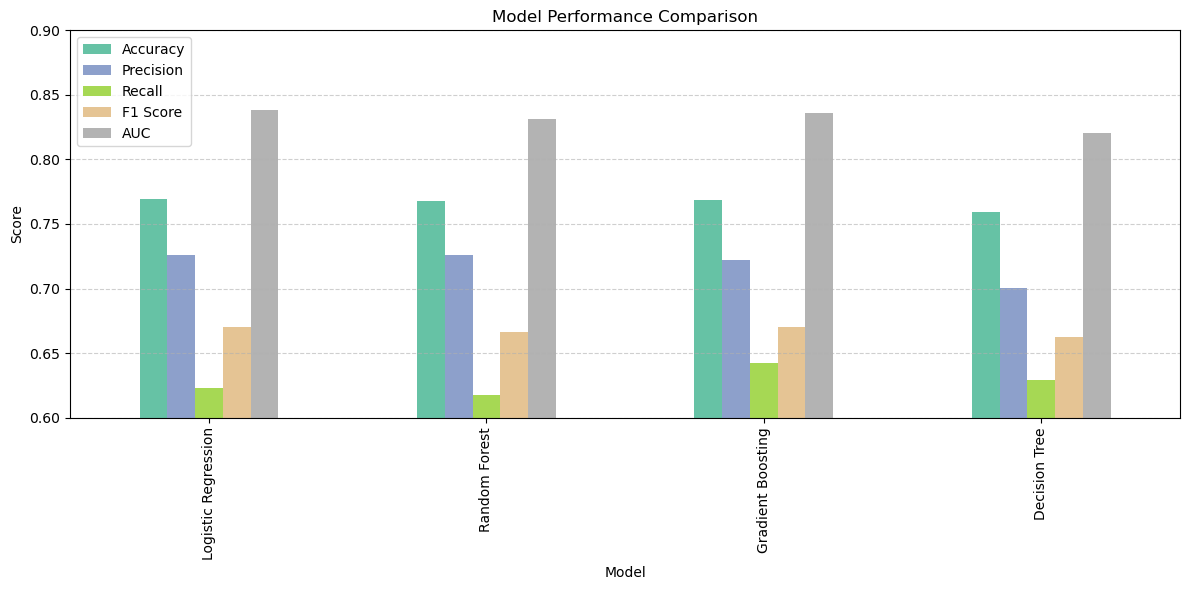

In [192]:
results = {
    'Logistic Regression': {
        'Accuracy': accuracy_logreg,
        'Precision': precision_logreg,
        'Recall': recall_logreg,
        'F1 Score': f1_logreg,
        'AUC': auc_logreg
    },
    'Random Forest': {
        'Accuracy': accuracy_rf,
        'Precision': precision_rf,
        'Recall': recall_rf,
        'F1 Score': f1_rf,
        'AUC': auc_rf
    },
    'Gradient Boosting': {
        'Accuracy': accuracy_gb,
        'Precision': precision_gb,
        'Recall': recall_gb,
        'F1 Score': f1_gb,
        'AUC': auc_gb
    },
    'Decision Tree': {
        'Accuracy': accuracy_tree,
        'Precision': precision_tree,
        'Recall': recall_tree,
        'F1 Score': f1_tree,
        'AUC': auc_tree
    }
}

# Create DataFrame
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

# Display table
display(results_df)

# Plot performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
plt.figure(figsize=(12, 6))
results_df.set_index('Model')[metrics].plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.6, 0.9)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


This chart compares the four models across five key metrics: Accuracy, Precision, Recall, F1 Score, and AUC. Overall:

- Logistic Regression performs consistently well across all metrics and offers strong interpretability, making it a robust baseline.
- Gradient Boosting delivers the best balance of recall and AUC, making it particularly useful for identifying high-risk borrowers.
- Random Forest achieves similar performance but with slightly lower recall, though still competitive.
- Decision Tree, while simpler and easier to interpret, underperforms the others slightly across all metrics.

Given these results, Gradient Boosting is the most promising for deployment when maximizing discriminatory power (AUC) is key, while Logistic Regression remains useful for transparent, interpretable decisions.

We could also do some cross validation. 

Logistic Regression CV AUC Scores: [0.8283 0.8331 0.8379 0.8325 0.8299]
Mean AUC: 0.8323 | Std Dev: 0.0033
------------------------------------------------------------
Random Forest CV AUC Scores: [0.8229 0.8253 0.8297 0.8263 0.824 ]
Mean AUC: 0.8256 | Std Dev: 0.0023
------------------------------------------------------------
Gradient Boosting CV AUC Scores: [0.8281 0.8307 0.8347 0.8291 0.8293]
Mean AUC: 0.8304 | Std Dev: 0.0023
------------------------------------------------------------
Decision Tree CV AUC Scores: [0.8114 0.816  0.8202 0.8135 0.8161]
Mean AUC: 0.8154 | Std Dev: 0.0029
------------------------------------------------------------


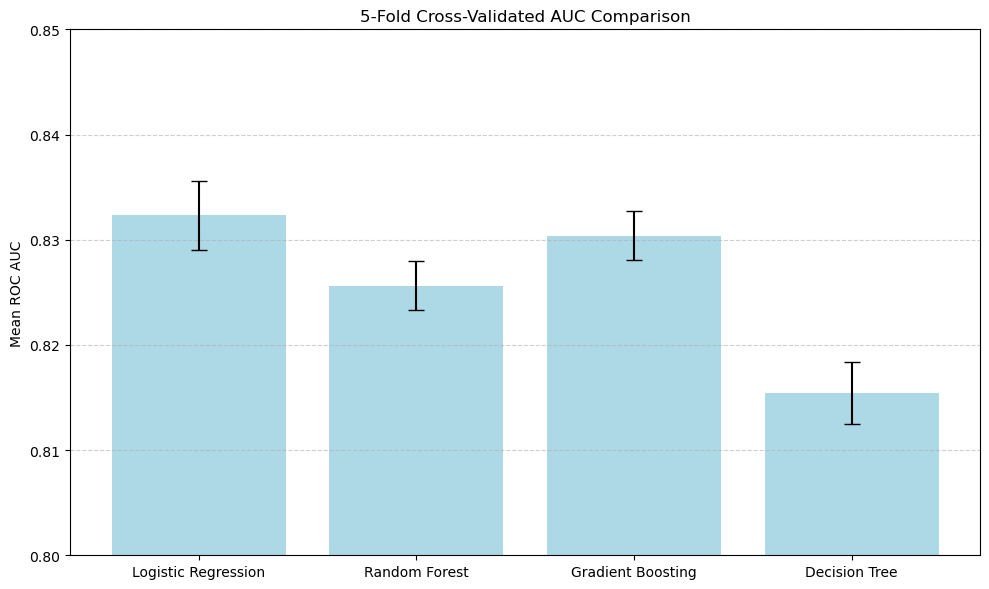

,Model,Mean AUC,Std Dev
0,Logistic Regression,0.832342,0.003286
1,Random Forest,0.825647,0.002333
2,Gradient Boosting,0.830378,0.002326
3,Decision Tree,0.815440,0.002949


In [196]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    'Logistic Regression': best_lr_model,
    'Random Forest': rf_best,
    'Gradient Boosting': best_gb_model,
    'Decision Tree': best_tree_model
}

# Storage
cv_results = {}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate each model
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name} CV AUC Scores: {np.round(scores, 4)}")
    print(f"Mean AUC: {np.mean(scores):.4f} | Std Dev: {np.std(scores):.4f}")
    print("-" * 60)

# Create summary DataFrame
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean AUC': [np.mean(v) for v in cv_results.values()],
    'Std Dev': [np.std(v) for v in cv_results.values()]
})

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(cv_summary['Model'], cv_summary['Mean AUC'], yerr=cv_summary['Std Dev'], capsize=6, color='lightblue')
plt.ylabel("Mean ROC AUC")
plt.title("5-Fold Cross-Validated AUC Comparison")
plt.ylim(0.80, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Display results
cv_summary
